In [26]:
%load_ext autoreload
%autoreload 2

import scanpy as sc


from pathlib import Path

cwd = Path.cwd()
ANALYSIS_DIR = (
    cwd
    if cwd.name == "06_b_cell_igvf"
    else Path("06_b_cell_igvf")
    if Path("06_b_cell_igvf").exists()
    else Path("..").resolve()
    if cwd.name == "notebooks"
    else Path("../..").resolve()
)
DATA_DIR = Path("data/flowmap_manuscript/b_cell")
if not DATA_DIR.exists():
    DATA_DIR = ANALYSIS_DIR.parent / "data" / "flowmap_manuscript" / "b_cell"
RESULTS_DIR = Path("data/flowmap_manuscript/b_cell_results")
if not RESULTS_DIR.exists():
    RESULTS_DIR = ANALYSIS_DIR.parent / "data" / "flowmap_manuscript" / "b_cell_results"
FIGURE_DIR = ANALYSIS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
UTILS_DIR = ANALYSIS_DIR / "utils"

adata = sc.read_h5ad(DATA_DIR / "bcell_velocity_standard.h5ad")
adata

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


AnnData object with n_obs × n_vars = 24330 × 2000
    obs: 'n_counts', 'n_genes', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'leiden', 'celltype'
    var: 'n_cells', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'original_id', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'recover_dynamics', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_flowmap', 'X_pca', 'X_umap', 'velocity_flowmap', 'velocity_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'ambiguous', 'fit_t', 'fit_tau', 'fit_tau_', 'matur

In [27]:
import scvelo as scv
import scanpy as sc
import anndata
import numpy as np
import sys
import numba, loompy

print("python:", sys.version)
print("scvelo:", scv.__version__)
print("scanpy:", sc.__version__)
print("anndata:", anndata.__version__)
print("numpy:", np.__version__)
print("numba:", numba.__version__)
print("loompy:", loompy.__version__)

python: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
scvelo: 0.3.3
scanpy: 1.11.4
anndata: 0.11.3
numpy: 2.2.6
numba: 0.62.1
loompy: 3.0.8


In [28]:
import flowmap
from flowmap import *
import pickle

with open(DATA_DIR / "flowmap_emb.pkl", "rb") as f:
    emb = pickle.load(f)

emb

In [29]:
# Simple clustering used for marker summaries.
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata, resolution=0.6)
adata.obsm["X_flowmap"] = emb.X_emb
adata.obs["leiden"].value_counts().sort_index()


leiden
0     5427
1     3127
2     2807
3     2505
4     2209
5     2156
6     1584
7     1305
8     1270
9      695
10     610
11     375
12     260
Name: count, dtype: int64

In [30]:
markers = {
    "Naive": ["GRASP", "ZNF331", "IRS2", "LIX1-AS1", "NR4A2", "KCNH8", "DUSP1", "RASGEF1B", "FOSB", "ZBTB10"],
    "ActB": ["ITGA1", "JAZF1", "SMIM14", "AC083837.1", "ST6GALNAC3", "IL7", "NIBAN3"],
    "preGCBC": ["KIAA1549L", "CFI", "HOMER2", "EEPD1", "PALLD", "SLC37A3", "FCER2"],
    "prePB": ["IL2RB", "IL2RA", "CD226", "DUSP4", "ACSL4", "CLIC5", "IL12RB2"],
    "PB": ["CFAP54", "AL591518.1", "ACOXL", "FNDC3B", "AC016074.2", "NUGGC", "RASSF6", "ZNF215"]
}

markers_filtered = {}

for key, gene_list in markers.items():
    genes_present = [g for g in gene_list if g in adata.var_names]
    if len(genes_present) > 0:
        markers_filtered[key] = genes_present

markers_filtered

{'Naive': ['ZNF331', 'LIX1-AS1', 'NR4A2', 'KCNH8', 'RASGEF1B', 'ZBTB10'],
 'ActB': ['ITGA1', 'JAZF1', 'SMIM14', 'ST6GALNAC3', 'IL7', 'NIBAN3'],
 'preGCBC': ['KIAA1549L', 'HOMER2', 'EEPD1', 'PALLD', 'SLC37A3', 'FCER2'],
 'prePB': ['IL2RA', 'CD226', 'DUSP4', 'ACSL4', 'CLIC5', 'IL12RB2'],
 'PB': ['CFAP54', 'ACOXL', 'FNDC3B', 'NUGGC', 'RASSF6', 'ZNF215']}

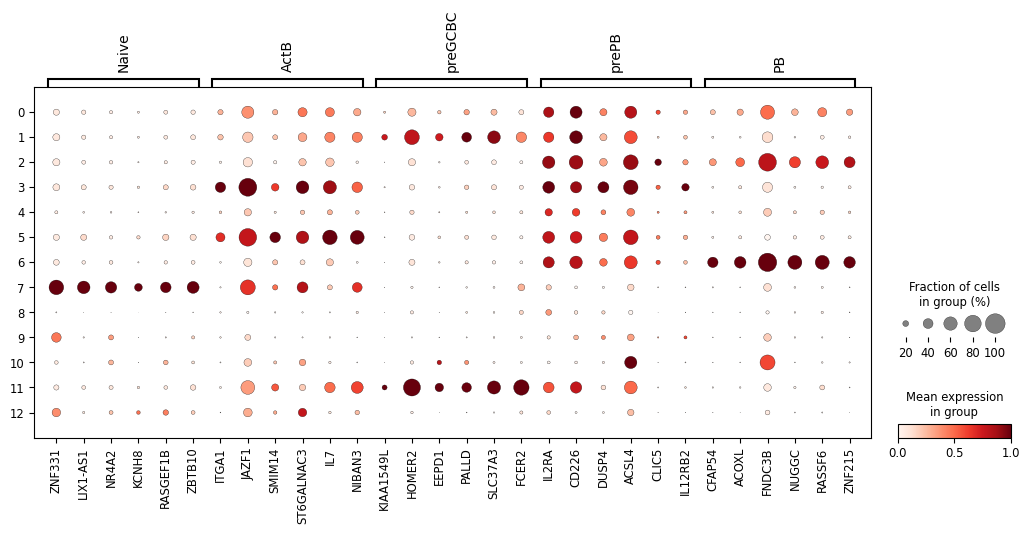

In [31]:
import scanpy as sc
sc.pl.dotplot(
    adata,
    markers_filtered,
    groupby='leiden',
    standard_scale='var'
)

In [32]:
cluster_map = {
    "0": "prePB",
    "1": "PreGCBC",
    "2": "PB",
    "3": "ActB",
    "4": "ActB",
    "5": "ActB",
    "6": "PB",
    "7": "Naive",
    "8": "Naive",
    "9": "Naive",
    "10": "Naive",
    "11": "PreGCBC",
    "12": "Naive",
}

adata.obs["bcell_cluster_label"] = (
    adata.obs["leiden"].astype(str).map(cluster_map).astype("category")
)
adata.obs[["leiden", "bcell_cluster_label"]].value_counts().sort_index()


leiden  bcell_cluster_label
0       prePB                  5427
1       PreGCBC                3127
2       PB                     2807
3       ActB                   2505
4       ActB                   2209
5       ActB                   2156
6       PB                     1584
7       Naive                  1305
8       Naive                  1270
9       Naive                   695
10      Naive                   610
11      PreGCBC                 375
12      Naive                   260
Name: count, dtype: int64

30 marker genes found.
Using original label key: celltype


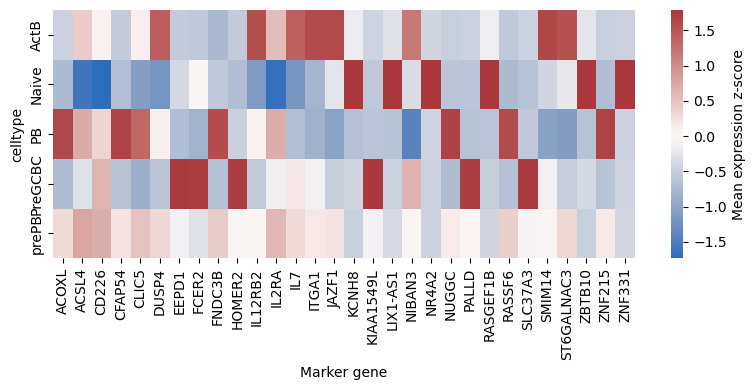

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use the original labels already stored on the AnnData object.
# If absent, fall back to the simple labels assigned from Leiden clusters above.
original_label_key = "celltype" if "celltype" in adata.obs else "bcell_cluster_label"
celltypes = adata.obs[original_label_key].astype("category")

genes = sorted({
    gene
    for gene_list in markers_filtered.values()
    for gene in gene_list
    if gene in adata.var_names
})

print(f"{len(genes)} marker genes found.")
print(f"Using original label key: {original_label_key}")

def compute_mean_expression(group_labels, genes):
    groups = pd.Categorical(group_labels)
    cats = groups.categories

    expr = pd.DataFrame(index=cats, columns=genes, dtype=float)

    for ct in cats:
        mask = groups == ct
        X = adata[mask, genes].X
        if hasattr(X, "toarray"):
            X = X.toarray()
        expr.loc[ct] = np.asarray(X).mean(axis=0)

    return (expr - expr.mean(axis=0)) / (expr.std(axis=0) + 1e-8)

expr_orig = compute_mean_expression(celltypes, genes)

fig_width = max(8, 0.25 * len(genes))
fig_height = max(4, 0.45 * len(expr_orig.index))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.heatmap(
    expr_orig,
    cmap="vlag",
    center=0,
    ax=ax,
    cbar_kws={"label": "Mean expression z-score"},
)
ax.set_xlabel("Marker gene")
ax.set_ylabel(original_label_key)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "bcell_original_label_marker_heatmap.pdf", bbox_inches="tight")
plt.show()


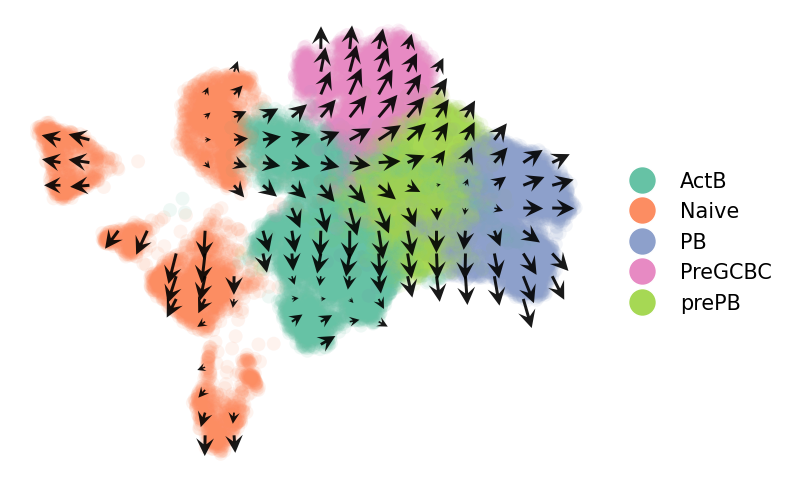

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.neighbors import NearestNeighbors
from flowmap.utils import compute_velocity_on_grid


# ------------------------------------------------------------
# Helper: remove grid seeds outside the manifold
# ------------------------------------------------------------
def points_inside_mask(X_emb, seeds, k=8, radius_scale=1.2):
    nn = NearestNeighbors(n_neighbors=k).fit(X_emb)
    r = np.median(nn.kneighbors(X_emb)[0][:, -1]) * radius_scale
    neigh_idx = nn.radius_neighbors(seeds, radius=r, return_distance=False)
    return np.array([len(ix) > 0 for ix in neigh_idx])


# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
X_emb = emb.X_emb
# Reuse original labels selected above for the heatmap.
celltypes = celltypes.astype("category")
codes = celltypes.cat.codes
categories = celltypes.cat.categories
# ------------------------------------------------------------
# Velocity grid (sparser)
# ------------------------------------------------------------
Xg, keep_mass, Vg = compute_velocity_on_grid(
    X_emb,
    spline_vf=emb.spline_vf,
    grid_size=20,          # ↓ sparser grid
    min_mass=0.01
)

keep_inside = points_inside_mask(X_emb, Xg)
Xg = Xg[keep_inside]
Vg = Vg[keep_inside]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
# cmap = plt.get_cmap("tab20", len(categories))  # good for up to ~20 types
colors = plt.get_cmap("Set2").colors  # soft + distinct
color_list = [colors[i % len(colors)] for i in range(len(categories))]
# scatter (larger + more transparent)
sc = ax.scatter(
    X_emb[:, 0],
    X_emb[:, 1],
    # c=velocity_pseudotime,
    # cmap="viridis",
    # c=codes,
    c=[color_list[i] for i in codes],
    # cmap=cmap,
    s=100,
    alpha=0.1,
    linewidths=0,
)

# velocity arrows (thicker + bigger heads)
ax.quiver(
    Xg[:, 0], Xg[:, 1],
    Vg[:, 0], Vg[:, 1],
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.005,         # ↑ thicker
    headwidth=6.0,       # ↑ bigger head
    headlength=6.0,
    headaxislength=4.0,
    minlength=0.2,
    color="k",
    alpha=0.9,
)

# for i, cat in enumerate(categories):
#     mask = (codes == i)
#     if np.sum(mask) == 0:
#         continue
    
#     x_mean = X_emb[mask, 0].mean()
#     y_mean = X_emb[mask, 1].mean()
    
#     ax.text(
#         x_mean,
#         y_mean,
#         cat,
#         fontsize=20,
#         weight="bold",
#         ha="center",
#         va="center",
#         color="black",
#         bbox=dict(
#             boxstyle="round,pad=0.2",
#             facecolor="white",
#             alpha=0.7,
#             linewidth=0
#         )
#     )
    
# ------------------------------------------------------------
# Styling (no legend / no colorbar)
# ------------------------------------------------------------
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=cat,
        markerfacecolor=color_list[i],
        markersize=20
    )
    for i, cat in enumerate(categories)
]

ax.legend(
    handles=legend_elements,
    fontsize=15,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "bcell_velocity_stream.pdf",  # updated path
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [35]:
from flowmap.geometry.curvature import compute_flow_curvature

curv = compute_flow_curvature(emb)

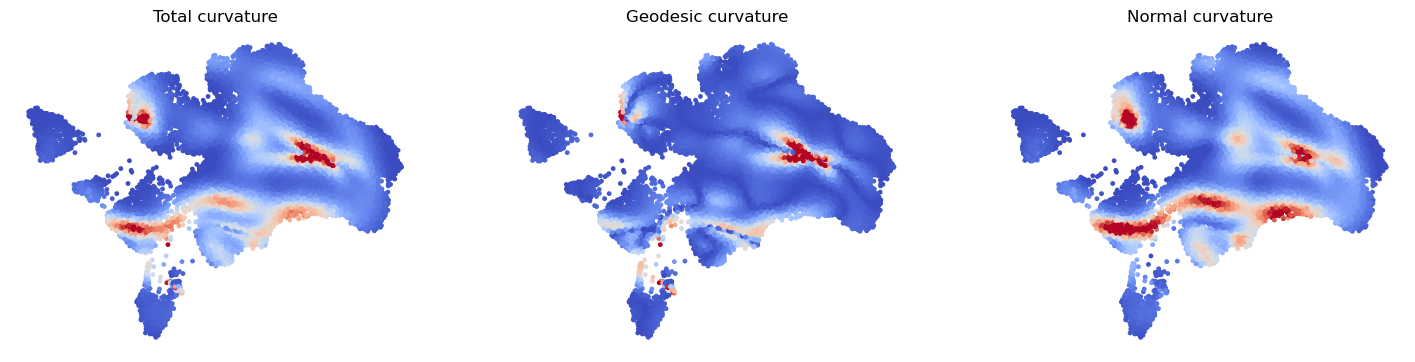

In [36]:
X = emb.X_emb

k_total  = curv["curvature"]["total"]
k_steer   = curv["curvature"]["steer"]
k_surface = curv["curvature"]["surface"]

def clip_quantile(arr, q_low=2, q_high=98):
    lo, hi = np.percentile(arr, [q_low, q_high])
    return np.clip(arr, lo, hi)

k_total_c  = clip_quantile(k_total)
k_steer_c   = clip_quantile(k_steer)
k_surface_c = clip_quantile(k_surface)

fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].scatter(X[:,0], X[:,1], c=k_total_c, s=6, cmap="coolwarm")
axes[0].set_title("Total curvature")

axes[1].scatter(X[:,0], X[:,1], c=k_steer_c, s=6, cmap="coolwarm")
axes[1].set_title("Geodesic curvature")

axes[2].scatter(X[:,0], X[:,1], c=k_surface_c, s=6, cmap="coolwarm")
axes[2].set_title("Normal curvature")

for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")

plt.savefig(FIGURE_DIR / "curvature_panels.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
del k_steer, k_steer_c

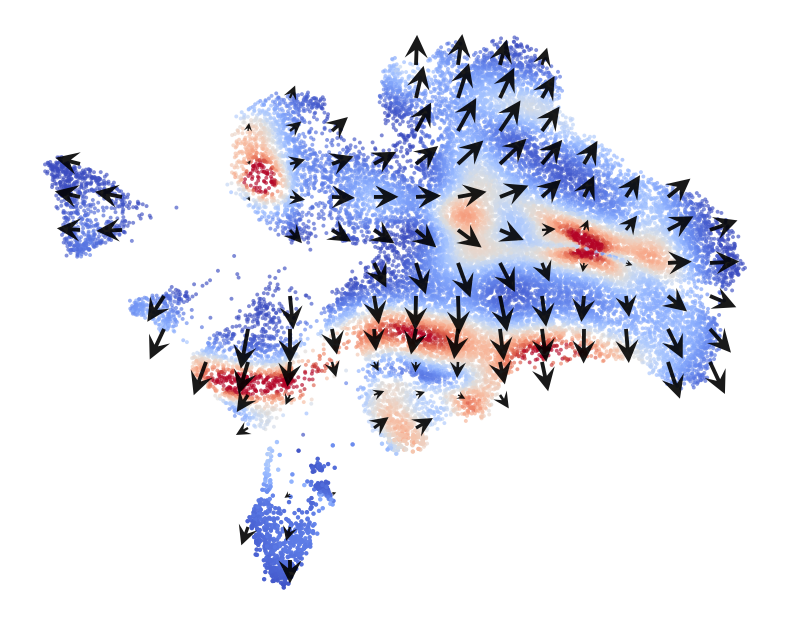

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle


fig, ax = plt.subplots(figsize=(8, 8))

# ------------------------------------------------------------
# Velocity grid (sparser)
# ------------------------------------------------------------
Xg, keep_mass, Vg = compute_velocity_on_grid(
    X_emb,
    spline_vf=emb.spline_vf,
    grid_size=18,          # ↓ sparser grid
    min_mass=0.01
)

keep_inside = points_inside_mask(X_emb, Xg)
Xg = Xg[keep_inside]
Vg = Vg[keep_inside]


# ------------------------------------------------------------
# Colormap normalization (shift white downward)
# ------------------------------------------------------------
vmin = np.percentile(k_surface_c, 2)
vmax = np.percentile(k_surface_c, 98)

# shift center slightly negative → more red overall
norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.4,
    vmax=vmax
)

# ------------------------------------------------------------
# Highlight region (your box)
# ------------------------------------------------------------
x1, x2 = 4.5, 10.0
y1, y2 = -3.0, 2.0

# ------------------------------------------------------------
# Define mask for highlighted region
# ------------------------------------------------------------
mask_box = (
    (X_emb[:, 0] > x1) & (X_emb[:, 0] < x2) &
    (X_emb[:, 1] > y1) & (X_emb[:, 1] < y2)
)

# ------------------------------------------------------------
# Background scatter (bottom)
# ------------------------------------------------------------
sc = ax.scatter(
    X_emb[:, 0],
    X_emb[:, 1],
    c=k_surface_c,
    cmap="coolwarm",
    norm=norm,
    s=8,
    alpha=0.65,
    linewidths=0,
    zorder=1
)

# ------------------------------------------------------------
# Optional highlight (still scatter layer)
# ------------------------------------------------------------
ax.scatter(
    X_emb[mask_box, 0],
    X_emb[mask_box, 1],
    c=k_surface_c[mask_box],
    cmap="coolwarm",
    norm=norm,
    s=10,
    alpha=0.9,
    linewidths=0,
    zorder=2
)

# ------------------------------------------------------------
# Rectangle (middle)
# ------------------------------------------------------------
# rect = Rectangle(
#     (x1, y1),
#     x2 - x1,
#     y2 - y1,
#     linewidth=4.5,
#     edgecolor="#2ca02c",
#     facecolor="none",
#     linestyle="--",
#     zorder=3
# )
# ax.add_patch(rect)

# ------------------------------------------------------------
# Velocity arrows (top layer)
# ------------------------------------------------------------
ax.quiver(
    Xg[:, 0], Xg[:, 1],
    Vg[:, 0], Vg[:, 1],
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.005,
    headwidth=6.0,
    headlength=6.0,
    headaxislength=4.0,
    minlength=0.2,
    color="k",
    alpha=0.9,
    zorder=4
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "bcell_surface_curvature_velocity_stream.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

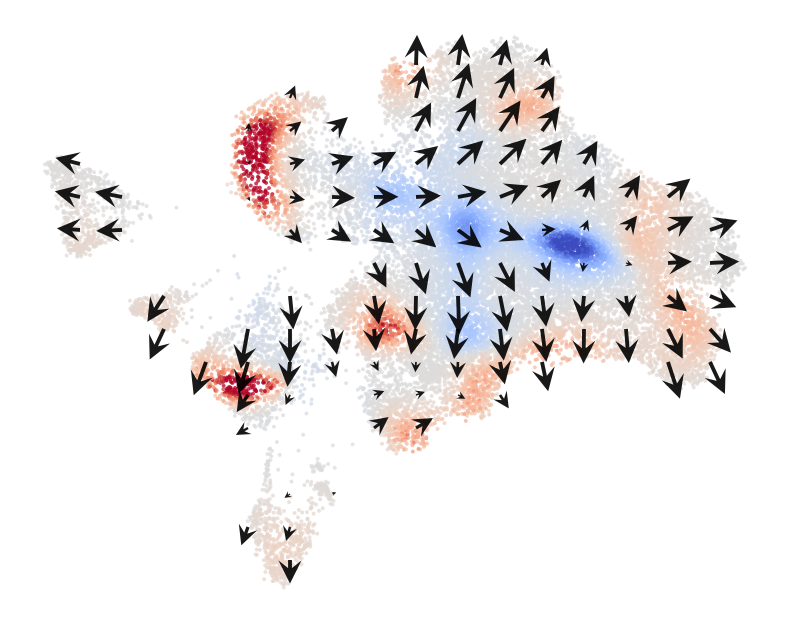

In [39]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from flowmap.utils import compute_velocity_on_grid


# ============================================================
# Curvature
# ============================================================

K, Riem, Ric, Rsc, Nmat = emb.spline.curvature(emb.X_emb)

# ------------------------------------------------------------
# symmetric clipping around zero
# ------------------------------------------------------------

clip_q = 98

absmax = np.percentile(np.abs(Rsc), clip_q)

Rsc_plot = np.clip(Rsc, -absmax, absmax)

norm = TwoSlopeNorm(
    vmin=-absmax,
    vcenter=0.0,
    vmax=absmax,
)


# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))


# ============================================================
# Velocity grid
# ============================================================

Xg, keep_mass, Vg = compute_velocity_on_grid(
    emb.X_emb,
    spline_vf=emb.spline_vf,
    grid_size=18,
    min_mass=0.01,
)

keep_inside = points_inside_mask(emb.X_emb, Xg)

Xg = Xg[keep_inside]
Vg = Vg[keep_inside]


# ============================================================
# Scatter
# ============================================================

sc = ax.scatter(
    emb.X_emb[:, 0],
    emb.X_emb[:, 1],
    c=Rsc_plot,
    cmap="coolwarm",
    norm=norm,
    s=8,
    alpha=0.75,
    linewidths=0,
    zorder=1,
)


# ============================================================
# Velocity arrows
# ============================================================

ax.quiver(
    Xg[:, 0],
    Xg[:, 1],
    Vg[:, 0],
    Vg[:, 1],
    angles="xy",
    scale_units="xy",
    scale=7,
    width=0.005,
    headwidth=6.0,
    headlength=6.0,
    headaxislength=4.0,
    minlength=0.2,
    color="k",
    alpha=0.9,
    zorder=4,
)



# ============================================================
# Styling
# ============================================================

ax.set_aspect("equal")

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()


# ============================================================
# Save
# ============================================================

plt.savefig(
    FIGURE_DIR / "bcell_ricci_scalar_velocity.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

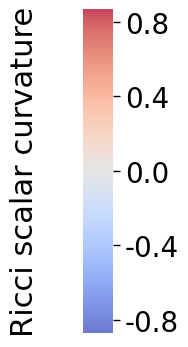

In [40]:
# ============================================================
# Standalone thin colorbar
# ============================================================

fig_cb, ax_cb = plt.subplots(figsize=(0.38, 4.2))

cbar = plt.colorbar(
    sc,
    cax=ax_cb,
)

# ============================================================
# USER OPTIONS
# ============================================================

tick_side  = "right"   # "left" or "right"
label_side = "left"  # "left" or "right"

# ============================================================
# ticks
# ============================================================

ticks = [-0.8, -0.4, 0.0, 0.4, 0.8]

cbar.set_ticks(ticks)

cbar.ax.set_yticklabels(
    [f"{t:.1f}" for t in ticks],
    fontsize=20,
)

# move ticks
cbar.ax.yaxis.set_ticks_position(tick_side)

# ============================================================
# label
# ============================================================

cbar.set_label(
    "Ricci scalar curvature",
    rotation=270,
    labelpad=32,
    fontsize=22,
)

# move label independently
cbar.ax.yaxis.set_label_position(label_side)

# fix rotation direction if label on left
if label_side == "left":
    cbar.ax.yaxis.label.set_rotation(90)
else:
    cbar.ax.yaxis.label.set_rotation(270)

# ============================================================
# remove black box
# ============================================================

cbar.outline.set_visible(False)

for spine in ax_cb.spines.values():
    spine.set_visible(False)

# ============================================================
# tick styling
# ============================================================

ax_cb.tick_params(
    labelsize=20,
    width=1.0,
    length=5,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "bcell_ricci_scalar_colorbar.pdf",
    dpi=400,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

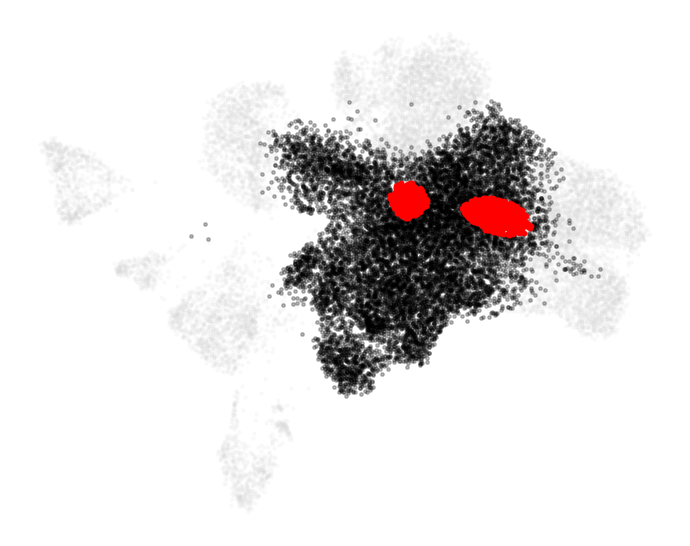

,names,scores,logfoldchanges,pvals,pvals_adj
0,IGHM,18.618011,0.644700,2.295834e-77,4.591668e-74
1,JCHAIN,16.859629,0.849344,8.914626e-64,8.914626e-61
2,HSP90B1,11.904634,0.453742,1.119525e-32,6.784999e-31
3,ENAM-AS1,11.407318,1.169140,3.843977e-30,1.239993e-28
4,CEP128,10.277626,0.653958,8.888977e-25,1.388903e-23
5,FNDC3B,8.415394,0.945272,3.915768e-17,2.071835e-16
6,ACTB,7.888165,0.209601,3.066630e-15,1.241551e-14
7,FNDC3A,7.844479,0.390470,4.347554e-15,1.739022e-14
8,ANKRD28,7.559667,0.549817,4.041031e-14,1.450999e-13
9,GLCCI1,6.254394,0.499431,3.990637e-10,8.950191e-10


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc


# ============================================================
# Select cell types
# ============================================================

celltypes_arr = np.array(celltypes)

keep_ct = np.isin(
    celltypes_arr,
    ["ActB", "prePB"]
)

# negative Ricci cells
neg_thr = np.percentile(Rsc, 5)
neg_mask = Rsc < neg_thr


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

# all cells
ax.scatter(
    emb.X_emb[:, 0],
    emb.X_emb[:, 1],
    c="lightgrey",
    s=5,
    alpha=0.08,
)

# ActB + prePB
ax.scatter(
    emb.X_emb[keep_ct, 0],
    emb.X_emb[keep_ct, 1],
    c="black",
    s=6,
    alpha=0.25,
)

# negative curvature cells
ax.scatter(
    emb.X_emb[keep_ct & neg_mask, 0],
    emb.X_emb[keep_ct & neg_mask, 1],
    c="red",
    s=10,
    alpha=0.95,
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Differential expression
# ============================================================

adata_sub = adata[keep_ct].copy()

adata_sub.obs["ricci_group"] = np.where(
    neg_mask[keep_ct],
    "negative",
    "other",
)

sc.tl.rank_genes_groups(
    adata_sub,
    groupby="ricci_group",
    groups=["negative"],
    reference="other",
    method="wilcoxon",
)

markers = sc.get.rank_genes_groups_df(
    adata_sub,
    group="negative",
)

markers.head(50)

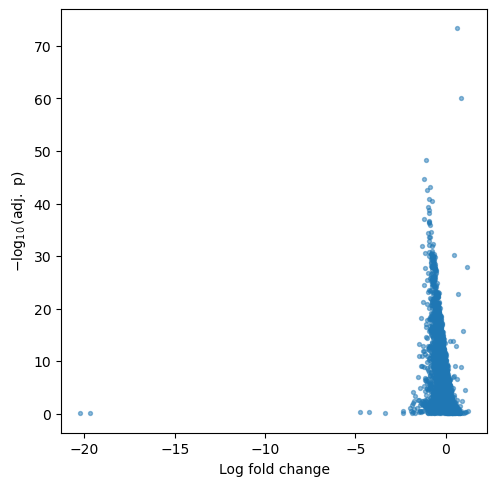

In [42]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DE results
# ============================================================

df = markers.copy()

x = df["logfoldchanges"].values

y = -np.log10(
    df["pvals_adj"].values + 1e-300
)


# ============================================================
# Basic volcano
# ============================================================

fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(
    x,
    y,
    s=8,
    alpha=0.5,
)

ax.set_xlabel("Log fold change")
ax.set_ylabel(r"$-\log_{10}(\mathrm{adj.\ p})$")

plt.show()

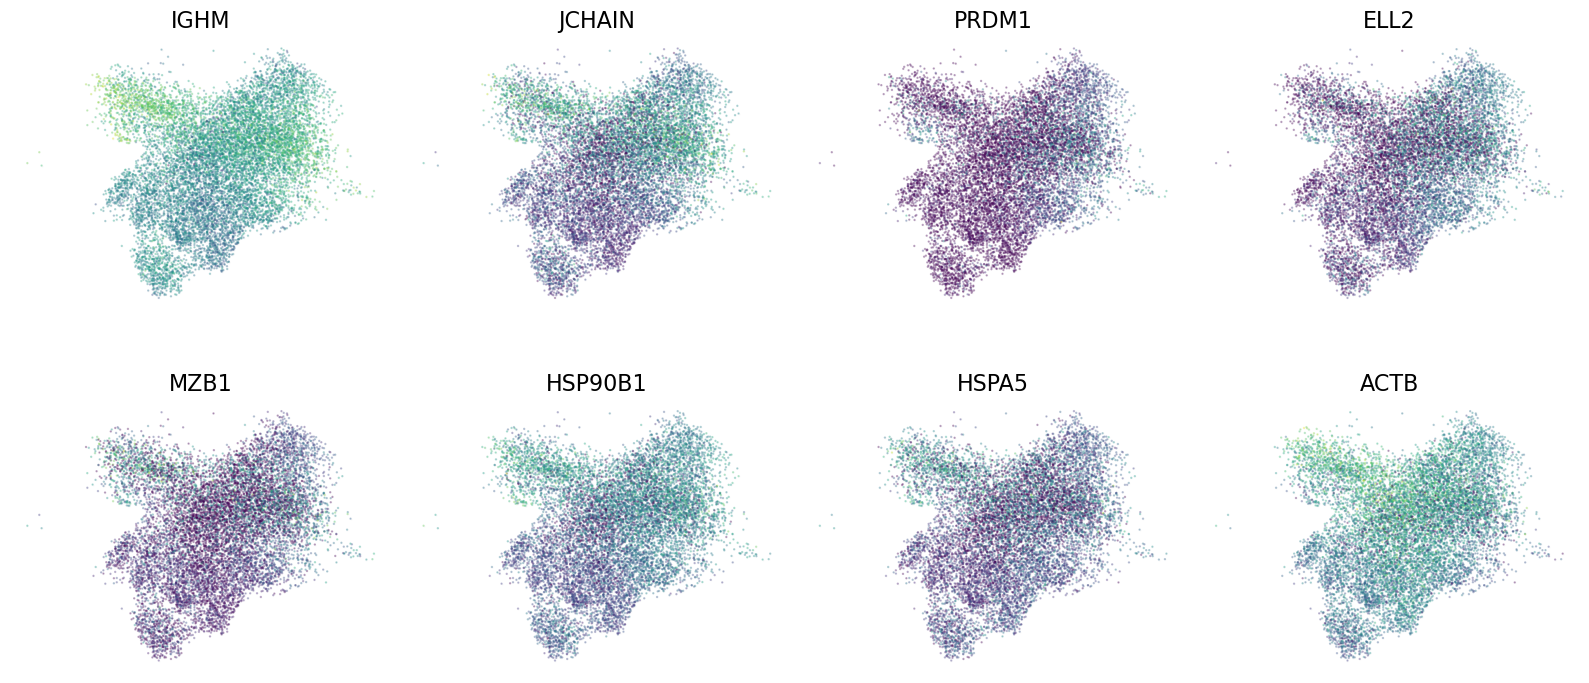

In [43]:
import numpy as np
import matplotlib.pyplot as plt


genes = [
    "IGHM",
    "JCHAIN",
    "PRDM1",
    "ELL2",
    "MZB1",
    "HSP90B1",
    "HSPA5",
    "ACTB",
]

celltypes_arr = np.array(celltypes)

keep_mask = np.isin(
    celltypes_arr,
    ["ActB", "prePB"]
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

axes = axes.ravel()


for ax, gene in zip(axes, genes):

    vals = adata[:, gene].X

    if hasattr(vals, "toarray"):
        vals = vals.toarray().ravel()
    else:
        vals = vals.ravel()

    vals = vals[keep_mask]

    # background selected cells only
    ax.scatter(
        emb.X_emb[keep_mask, 0],
        emb.X_emb[keep_mask, 1],
        c="lightgrey",
        s=0.5,
        alpha=0.08,
    )

    # expression overlay
    sca = ax.scatter(
        emb.X_emb[keep_mask, 0],
        emb.X_emb[keep_mask, 1],
        c=vals,
        cmap="viridis",
        s=0.5,
        alpha=0.3,
    )

    ax.set_title(
        gene,
        fontsize=16,
    )

    ax.set_aspect("equal")
    ax.axis("off")


plt.tight_layout()
plt.show()

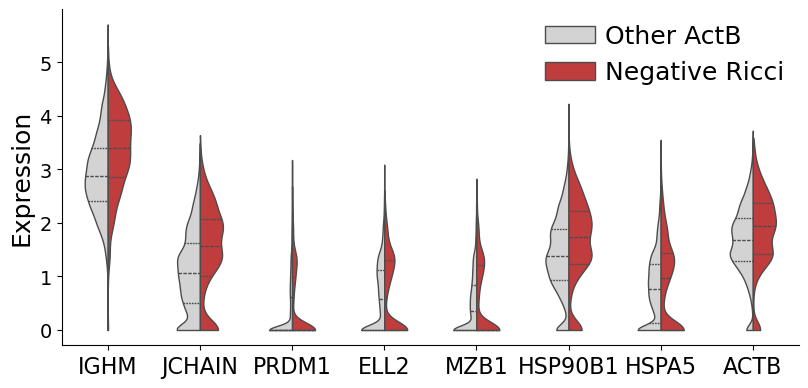

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Setup
# ============================================================

genes = [
    "IGHM",
    "JCHAIN",
    "PRDM1",
    "ELL2",
    "MZB1",
    "HSP90B1",
    "HSPA5",
    "ACTB",
]

celltypes_arr = np.array(celltypes)

keep_mask = np.isin(
    celltypes_arr,
    ["ActB", "prePB"]
)

neg_thr = np.percentile(Rsc, 10)
neg_mask = Rsc < neg_thr


# ============================================================
# Build dataframe
# ============================================================

dfs = []

for gene in genes:

    vals = adata[:, gene].X

    if hasattr(vals, "toarray"):
        vals = vals.toarray().ravel()
    else:
        vals = vals.ravel()

    dfs.append(pd.DataFrame({
        "expression": vals[keep_mask],
        "gene": gene,
        "group": np.where(
            neg_mask[keep_mask],
            "Negative Ricci",
            "Other ActB",
        )
    }))

df_plot = pd.concat(dfs, axis=0)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.8))

sns.violinplot(
    data=df_plot,
    x="gene",
    y="expression",
    hue="group",
    split=True,
    inner="quartile",
    cut=0,
    linewidth=1.0,
    width=.5,   # fatter violins
    scale="width",
    palette={
        "Negative Ricci": "#d62728",
        "Other ActB": "lightgrey",
    },
    ax=ax,
)

# ============================================================
# Styling
# ============================================================

ax.set_xlabel("")
ax.set_ylabel(
    "Expression",
    fontsize=18,
)

ax.tick_params(
    axis="x",
    labelsize=16,
    rotation=0,
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

# compact legend
leg = ax.legend(
    frameon=False,
    fontsize=18,
    loc="upper right",
    handletextpad=0.4,
    borderaxespad=0.2,
)

# remove extra seaborn title
leg.set_title(None)

# cleaner spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(
    pad=0.4,
)

plt.savefig(
    FIGURE_DIR / "bcell_negative_ricci_violin.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

In [45]:
adata_sub.obs["ricci_group"].value_counts()

ricci_group
other       11264
negative     1033
Name: count, dtype: int64

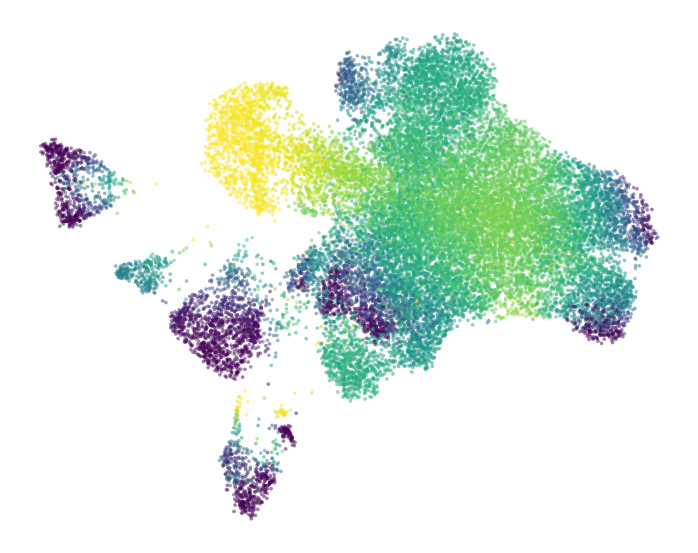

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Load entropy
# ============================================================

fate_entropy = pd.read_csv(
    RESULTS_DIR / "cellrank/bcell_cellrank_fate_entropy.csv"
)

barcode_to_entropy = dict(
    zip(
        fate_entropy["barcode"],
        fate_entropy["fate_entropy_normalized"],
    )
)

entropy = np.array([
    barcode_to_entropy[b]
    for b in adata.obs_names
])


# ============================================================
# Negative Ricci
# ============================================================

neg_thr = np.percentile(Rsc, 10)

neg_mask = Rsc < neg_thr


# ============================================================
# Clip entropy for cleaner contrast
# ============================================================

vmin = np.percentile(entropy, 1)
vmax = np.percentile(entropy, 99)

entropy_plot = np.clip(
    entropy,
    vmin,
    vmax,
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(6.8, 6.8))


# ------------------------------------------------------------
# Background cells
# ------------------------------------------------------------

ax.scatter(
    emb.X_emb[:, 0],
    emb.X_emb[:, 1],
    c="lightgrey",
    s=2,
    alpha=0.05,
    linewidths=0,
    zorder=1,
)


# ------------------------------------------------------------
# Entropy overlay
# ------------------------------------------------------------

sc = ax.scatter(
    emb.X_emb[:, 0],
    emb.X_emb[:, 1],
    c=entropy_plot,
    cmap="viridis",
    s=7,
    alpha=0.5,
    linewidths=0,
    zorder=2,
)


# ------------------------------------------------------------
# Negative Ricci outline
# ------------------------------------------------------------

# ax.scatter(
#     emb.X_emb[neg_mask, 0],
#     emb.X_emb[neg_mask, 1],
#     facecolors="none",
#     edgecolors="#00c8ff",
#     linewidths=0.35,
#     s=10,
#     alpha=0.1,
#     zorder=3,
# )


# ============================================================
# Styling
# ============================================================

ax.set_aspect("equal")

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(
    pad=0.05,
)


# ============================================================
# Save
# ============================================================

plt.savefig(
    FIGURE_DIR / "bcell_fate_entropy_overlay.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

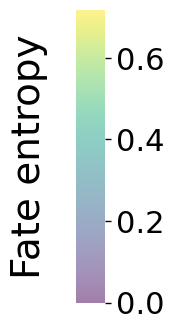

In [47]:
# ============================================================
# Standalone thin colorbar
# ============================================================

fig_cb, ax_cb = plt.subplots(figsize=(0.38, 3.8))

cbar = plt.colorbar(
    sc,
    cax=ax_cb,
)

# ------------------------------------------------------------
# sparse ticks
# ------------------------------------------------------------

# ticks = [0.0, 0.4, 0.8]

# cbar.set_ticks(ticks)

# cbar.ax.set_yticklabels(
#     [f"{t:.1f}" for t in ticks],
#     fontsize=18,
# )

# ------------------------------------------------------------
# label
# ------------------------------------------------------------



cbar.set_label(

    "Fate entropy",

    rotation=90,

    labelpad=20,

    fontsize=28,

)

cbar.ax.yaxis.set_label_position("left")

# ------------------------------------------------------------
# remove boundary
# ------------------------------------------------------------

cbar.outline.set_visible(False)

for spine in ax_cb.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# tick styling
# ------------------------------------------------------------

ax_cb.tick_params(
    labelsize=22,
    width=1.0,
    length=4,
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "bcell_fate_entropy_colorbar.pdf",
    dpi=400,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

In [48]:
fate_entropy

,barcode,fate_entropy,fate_entropy_normalized
0,AAACAGCCAAACTAAG_IGVFSM3641EGVH,0.578611,0.251288
1,AAACAGCCAACAGGTG_IGVFSM3641EGVH,1.054411,0.457925
2,AAACAGCCAACCTGGT_IGVFSM3641EGVH,1.504197,0.653264
3,AAACAGCCAAGTTATC_IGVFSM3641EGVH,0.000000,0.000000
4,AAACAGCCACCCACCT_IGVFSM3641EGVH,1.078984,0.468597
...,...,...,...
24325,TTTGTTGGTTGTGACA_IGVFSM3641EGVH,1.030744,0.447646
24326,TTTGTTGGTTTACTTG_IGVFSM3641EGVH,1.212118,0.526416
24327,TTTGTTGGTTTATGGG_IGVFSM3641EGVH,0.906920,0.393870
24328,TTTGTTGGTTTCCACG_IGVFSM3641EGVH,1.117409,0.485284


Pearson r = -0.4460
p-value   = 0.0000e+00


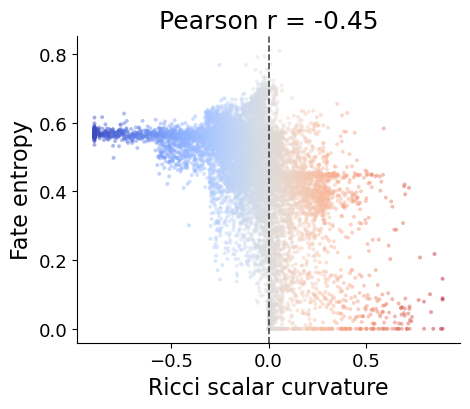

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# subset
# ============================================================

celltypes_arr = np.array(celltypes)

keep_mask = np.isin(
    celltypes_arr,
    ["ActB", "prePB"]
)

R_plot = Rsc[keep_mask]
E_plot = fate_entropy["fate_entropy_normalized"].values[keep_mask]


# ============================================================
# clipping
# ============================================================

clip_q = 99

absmax = np.percentile(
    np.abs(R_plot),
    clip_q,
)

R_plot = np.clip(
    R_plot,
    -absmax,
    absmax,
)


# ============================================================
# correlation
# ============================================================

r, p = pearsonr(R_plot, E_plot)

print(f"Pearson r = {r:.4f}")
print(f"p-value   = {p:.4e}")


# ============================================================
# plot
# ============================================================

fig, ax = plt.subplots(figsize=(4.8, 4.2))

sc = ax.scatter(
    R_plot,
    E_plot,
    c=R_plot,
    cmap="coolwarm",
    norm=TwoSlopeNorm(
        vmin=-absmax,
        vcenter=0.0,
        vmax=absmax,
    ),
    s=8,
    alpha=0.45,
    linewidths=0,
)

# zero line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
)

# labels
ax.set_xlabel(
    "Ricci scalar curvature",
    fontsize=16,
)

ax.set_ylabel(
    "Fate entropy",
    fontsize=16,
)

# ticks
ax.tick_params(
    axis="both",
    labelsize=13,
)

# title
ax.set_title(
    f"Pearson r = {r:.2f}",
    fontsize=18,
)

# styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "bcell_ricci_vs_entropy.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.show()

In [50]:
terminal_states = pd.read_csv(
    RESULTS_DIR / "cellrank/bcell_cellrank_terminal_states.csv"
)
terminal_nonan = terminal_states.dropna(subset=["terminal_state"])

barcode_to_terminal = dict(
    zip(
        terminal_nonan["barcode"],
        terminal_nonan["terminal_state"],
    )
)

terminal_labels = np.array([
    barcode_to_terminal.get(b, "other")
    for b in adata.obs_names
])

fig, ax = plt.subplots(figsize=(7, 7))

# background
ax.scatter(
    emb.X_emb[:, 0],
    emb.X_emb[:, 1],
    c="lightgrey",
    s=4,
    alpha=0.12,
)

# terminal states
mask_term = terminal_labels != "other"

ax.scatter(
    emb.X_emb[mask_term, 0],
    emb.X_emb[mask_term, 1],
    c="red",
    s=10,
    alpha=0.9,
)

# negative Ricci
ax.scatter(
    emb.X_emb[neg_mask, 0],
    emb.X_emb[neg_mask, 1],
    c="blue",
    s=8,
    alpha=0.7,
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

KeyError: ['terminal_state']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


genes = [
    "IGHM",
    "JCHAIN",
    "PRDM1",
    "ELL2",
    "HSP90B1",
    "HSPA5",
    "MZB1",
    "ENAM-AS1",
]


fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

axes = axes.ravel()


for ax, gene in zip(axes, genes):

    expr = adata[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.asarray(expr).ravel()

    # background
    ax.scatter(
        emb.X_emb[:, 0],
        emb.X_emb[:, 1],
        c="lightgrey",
        s=4,
        alpha=0.08,
    )

    # expression
    sc = ax.scatter(
        emb.X_emb[:, 0],
        emb.X_emb[:, 1],
        c=expr,
        cmap="viridis",
        s=6,
        alpha=0.9,
    )

    ax.set_title(
        gene,
        fontsize=16,
    )

    ax.set_aspect("equal")
    ax.axis("off")


plt.tight_layout()
plt.show()